In [2]:
import os
import pandas as pd
import numpy as np

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')

In [4]:
import seaborn as sns

In [5]:
import plotly.express as px

# Read in Ensemble model

In [6]:
mc = pd.read_csv("../models/ensemble_predictions.csv")

In [7]:
mc_keep_cols = ['pred_mean','pred_std','FULL_NAME','TEAM_NAME','ROUND_ROUNDNUMBER','MATCHID']
mc_subset = mc.loc[:,mc_keep_cols]

In [8]:
mc_subset

,pred_mean,pred_std,FULL_NAME,TEAM_NAME,ROUND_ROUNDNUMBER,MATCHID
0,-0.000509,0.000562,TAYLOR ADAMS,Sydney Swans,0,CD_M20250140002
1,0.020684,0.014397,JOEL AMARTEY,Sydney Swans,0,CD_M20250140002
2,0.121409,0.065305,NICK BLAKEY,Sydney Swans,0,CD_M20250140002
3,-0.000667,0.000947,BRAEDEN CAMPBELL,Sydney Swans,0,CD_M20250140002
4,-0.000363,0.000696,OLIVER FLORENT,Sydney Swans,0,CD_M20250140002
...,...,...,...,...,...,...
9524,0.009356,0.007489,MASON REDMAN,Essendon,24,CD_M20250142410
9525,0.033752,0.034805,ARCHIE ROBERTS,Essendon,24,CD_M20250142410
9526,0.021316,0.035066,DYLAN SHIEL,Essendon,24,CD_M20250142410
9527,-0.000493,0.000523,RHYS UNWIN,Essendon,24,CD_M20250142410


# Numpy beast mode!

In [9]:
n_sims = 1000
seed = 42
eps = 1e-6 # stops zero-scale issues

In [10]:
means = mc_subset['pred_mean'].to_numpy(dtype=float)
stds = mc_subset['pred_std'].to_numpy(dtype=float)

In [11]:
# sanitize stds: replace NaN/negative/zero with eps
stds = np.where(np.isfinite(stds) & (stds > eps), stds, eps)

In [12]:
# set RNG for reproducibility
rng = np.random.default_rng(seed)

In [13]:
samples = rng.normal(loc=means[:, None], scale=stds[:, None], size=(means.shape[0], n_sims))

In [14]:
# Create column names: simulation_1 ... simulation_n
sim_cols = [f"simulation_{i+1}" for i in range(n_sims)]
# Build DataFrame of simulations (keeps same row order as df)
sim_df = pd.DataFrame(samples, columns=sim_cols, index=mc_subset.index)
# Concatenate to original df (side-by-side)
mc_with_sims = pd.concat([mc_subset, sim_df], axis=1)

In [15]:
mc_with_sims

,pred_mean,pred_std,FULL_NAME,TEAM_NAME,ROUND_ROUNDNUMBER,MATCHID,simulation_1,simulation_2,simulation_3,simulation_4,...,simulation_991,simulation_992,simulation_993,simulation_994,simulation_995,simulation_996,simulation_997,simulation_998,simulation_999,simulation_1000
0,-0.000509,0.000562,TAYLOR ADAMS,Sydney Swans,0,CD_M20250140002,-0.000338,-0.001093,-0.000087,0.000019,...,-0.000020,0.000322,0.000499,0.000229,-0.000570,-0.000311,-0.000078,-0.000441,-0.000435,-0.000046
1,0.020684,0.014397,JOEL AMARTEY,Sydney Swans,0,CD_M20250140002,0.019830,0.010185,0.014717,0.029810,...,0.026309,0.028535,0.024019,0.034579,0.021949,0.026327,0.025058,0.019366,0.013042,0.052560
2,0.121409,0.065305,NICK BLAKEY,Sydney Swans,0,CD_M20250140002,0.091894,0.077924,0.149752,0.137856,...,0.163251,0.227686,0.117553,0.277501,0.089710,0.071355,0.042387,0.273635,0.174922,0.099589
3,-0.000667,0.000947,BRAEDEN CAMPBELL,Sydney Swans,0,CD_M20250140002,0.000517,-0.000015,0.001196,-0.002133,...,-0.000398,-0.001646,-0.000955,-0.001321,-0.000096,-0.001310,0.000292,-0.000899,-0.001282,-0.001854
4,-0.000363,0.000696,OLIVER FLORENT,Sydney Swans,0,CD_M20250140002,-0.000186,0.000260,-0.000172,0.001195,...,-0.001448,-0.000408,-0.000755,-0.000834,-0.000064,0.000387,-0.000601,0.000181,-0.000328,-0.000984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9524,0.009356,0.007489,MASON REDMAN,Essendon,24,CD_M20250142410,0.012512,0.019680,0.011205,0.016519,...,0.009088,0.007439,0.014910,0.021095,0.010527,0.009651,0.006477,0.015988,0.004426,0.002914
9525,0.033752,0.034805,ARCHIE ROBERTS,Essendon,24,CD_M20250142410,0.007133,0.041838,-0.021331,0.065133,...,0.009365,0.060493,0.020014,0.040811,-0.028400,0.025869,0.047069,0.029588,0.061912,0.013650
9526,0.021316,0.035066,DYLAN SHIEL,Essendon,24,CD_M20250142410,0.014402,0.056124,-0.042225,0.001931,...,0.025261,0.029047,0.056832,0.020975,-0.024111,0.015034,-0.005691,-0.048389,0.031769,0.125471
9527,-0.000493,0.000523,RHYS UNWIN,Essendon,24,CD_M20250142410,-0.000529,0.000580,-0.000525,-0.001196,...,-0.000695,-0.000623,-0.000297,-0.000666,0.000057,0.000072,-0.000972,-0.001502,-0.000317,-0.000028


In [16]:
match_col = 'MATCHID'

# sanity check that cols exist
missing = [c for c in sim_cols if c not in mc_with_sims.columns]
if missing:
    raise ValueError(f"Missing simulation cols: {missing[:5]}... (total {len(missing)})")

# Prepare a container for points columns (same index/order as df_with_sims)
points_cols = [f"{c}_pts" for c in sim_cols]
points_df = pd.DataFrame(index=mc_with_sims.index, columns=points_cols, dtype=np.int16)

In [17]:
# Loop over simulation columns and compute groupwise ranks -> points
for sim_col, pts_col in zip(sim_cols, points_cols):
    # rank within each MATCHID: best (largest) value gets rank 1
    ranks = mc_with_sims.groupby(match_col)[sim_col].transform(
        lambda s: s.rank(method='first', ascending=False)
    ).to_numpy(dtype=np.int32)

    # convert ranks to points: 1 -> 3, 2 -> 2, 3 -> 1, else 0
    pts = np.zeros_like(ranks, dtype=np.int16)
    pts[ranks == 1] = 3
    pts[ranks == 2] = 2
    pts[ranks == 3] = 1

    points_df[pts_col] = pts

In [18]:
# concat points back to original df (or keep separate)
df_with_points = pd.concat([mc_with_sims, points_df], axis=1)

In [19]:
df_with_points

,pred_mean,pred_std,FULL_NAME,TEAM_NAME,ROUND_ROUNDNUMBER,MATCHID,simulation_1,simulation_2,simulation_3,simulation_4,...,simulation_991_pts,simulation_992_pts,simulation_993_pts,simulation_994_pts,simulation_995_pts,simulation_996_pts,simulation_997_pts,simulation_998_pts,simulation_999_pts,simulation_1000_pts
0,-0.000509,0.000562,TAYLOR ADAMS,Sydney Swans,0,CD_M20250140002,-0.000338,-0.001093,-0.000087,0.000019,...,0,0,0,0,0,0,0,0,0,0
1,0.020684,0.014397,JOEL AMARTEY,Sydney Swans,0,CD_M20250140002,0.019830,0.010185,0.014717,0.029810,...,0,0,0,0,0,0,0,0,0,0
2,0.121409,0.065305,NICK BLAKEY,Sydney Swans,0,CD_M20250140002,0.091894,0.077924,0.149752,0.137856,...,0,1,0,0,0,0,0,1,0,0
3,-0.000667,0.000947,BRAEDEN CAMPBELL,Sydney Swans,0,CD_M20250140002,0.000517,-0.000015,0.001196,-0.002133,...,0,0,0,0,0,0,0,0,0,0
4,-0.000363,0.000696,OLIVER FLORENT,Sydney Swans,0,CD_M20250140002,-0.000186,0.000260,-0.000172,0.001195,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9524,0.009356,0.007489,MASON REDMAN,Essendon,24,CD_M20250142410,0.012512,0.019680,0.011205,0.016519,...,0,0,0,0,0,0,0,0,0,0
9525,0.033752,0.034805,ARCHIE ROBERTS,Essendon,24,CD_M20250142410,0.007133,0.041838,-0.021331,0.065133,...,0,0,0,0,0,0,0,0,0,0
9526,0.021316,0.035066,DYLAN SHIEL,Essendon,24,CD_M20250142410,0.014402,0.056124,-0.042225,0.001931,...,0,0,0,0,0,0,0,0,0,0
9527,-0.000493,0.000523,RHYS UNWIN,Essendon,24,CD_M20250142410,-0.000529,0.000580,-0.000525,-0.001196,...,0,0,0,0,0,0,0,0,0,0


# Plot expected round score

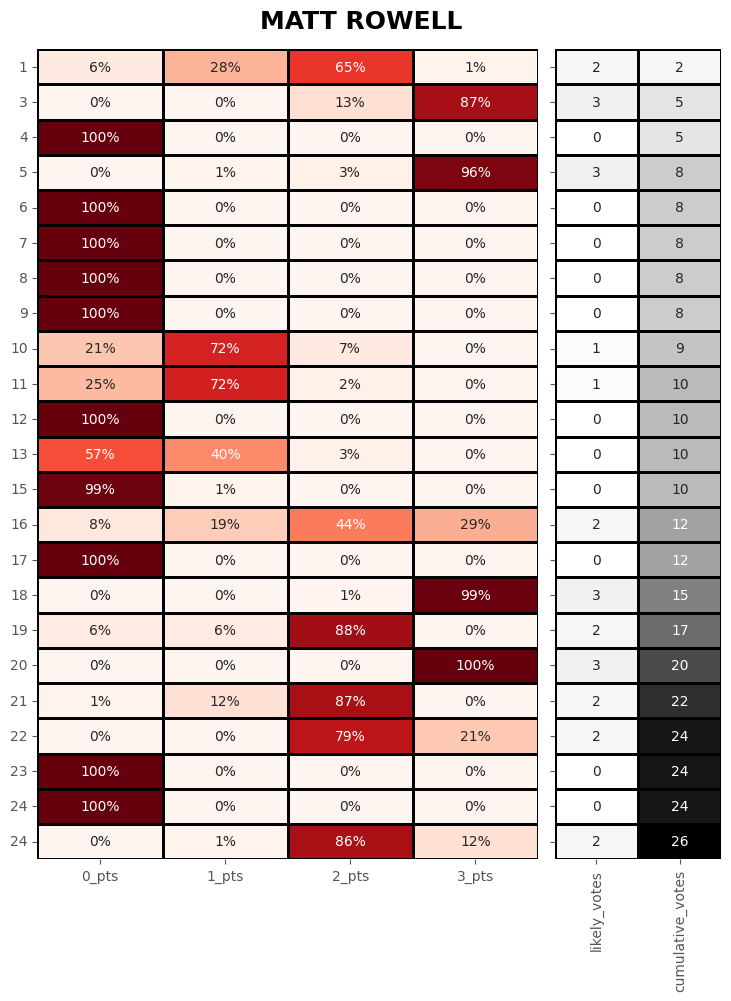

In [20]:
check_player = 'MATT ROWELL'
df_with_points_check = df_with_points.query(f"FULL_NAME == '{check_player}' ")

df_with_points_check_by_round = (df_with_points_check
                                .loc[:,['ROUND_ROUNDNUMBER'] + points_cols]
                                .set_index('ROUND_ROUNDNUMBER'))

df_3_pts = (df_with_points_check_by_round == 3).mean(axis=1).to_frame('3_pts')
df_2_pts = (df_with_points_check_by_round == 2).mean(axis=1).to_frame('2_pts')
df_1_pts = (df_with_points_check_by_round == 1).mean(axis=1).to_frame('1_pts')
df_0_pts = (df_with_points_check_by_round == 0).mean(axis=1).to_frame('0_pts')
df_with_points_check = pd.concat([df_0_pts, df_1_pts, df_2_pts, df_3_pts], axis=1)

fig, (ax_left, ax_right) = plt.subplots(
    ncols=2, nrows=1, figsize=(9, 10),
    gridspec_kw={'width_ratios': [3, 1]},
    sharey=True
)

sns.heatmap(df_with_points_check, ax=ax_left, cmap='Reds', annot=True, fmt=".0%", linewidths=0.8, linecolor='k', cbar=False)
ax_left.set_ylabel('')
ax_left.set_yticklabels(ax_left.get_yticklabels(), rotation=0, ha='right')

likely_votes = df_with_points_check_by_round.mode(axis=1)[0].squeeze().to_frame('likely_votes')
likely_votes_cumulative = likely_votes.cumsum().squeeze().to_frame('cumulative_votes')
likely_by_round = pd.concat([likely_votes, likely_votes_cumulative], axis=1)

sns.heatmap(
    likely_by_round,
    ax=ax_right,
    annot=likely_by_round,
    fmt='d',
    cmap='Greys',
    cbar=False,
    linewidths=0.8,
    linecolor='k'
)

ax_right.set_ylabel('')
fig.suptitle(check_player, fontsize=18, fontweight='bold', y=0.96)
# Reduce top margin so title sits closer to plots
fig.subplots_adjust(top=0.92, left=0.14, wspace=0.05);

# Wrapping things up

In [21]:
points_totals_by_player = (df_with_points
                           .groupby(['FULL_NAME','TEAM_NAME'])[points_cols]
                           .sum()
                           .reset_index())

points_totals_by_player

,FULL_NAME,TEAM_NAME,simulation_1_pts,simulation_2_pts,simulation_3_pts,simulation_4_pts,simulation_5_pts,simulation_6_pts,simulation_7_pts,simulation_8_pts,...,simulation_991_pts,simulation_992_pts,simulation_993_pts,simulation_994_pts,simulation_995_pts,simulation_996_pts,simulation_997_pts,simulation_998_pts,simulation_999_pts,simulation_1000_pts
0,AARON CADMAN,GWS GIANTS,5,5,5,5,5,5,5,5,...,5,5,5,5,5,5,5,5,6,5
1,AARON FRANCIS,Sydney Swans,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,AARON NAUGHTON,Western Bulldogs,8,8,8,8,9,7,9,6,...,9,8,9,9,8,9,7,8,9,8
3,ADAM CERRA,Carlton,5,5,4,4,4,5,4,4,...,4,5,5,5,5,5,4,5,5,4
4,ADAM SAAD,Carlton,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
664,ZAINE CORDY,St Kilda,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
665,ZAK BUTTERS,Port Adelaide,26,22,21,23,23,20,22,25,...,22,21,21,23,23,23,20,23,20,24
666,ZAK JOHNSON,Essendon,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
667,ZAK JONES,St Kilda,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
points_stats = points_totals_by_player[points_cols].agg(['min','max','mean','std'], axis=1)
points_stats = points_stats.add_prefix('simulation_')
points_totals_by_player = pd.concat([points_totals_by_player, points_stats], axis=1)

## Top Ranking Players

In [23]:
points_totals_by_player.sort_values(by='simulation_mean', ascending=False)

,FULL_NAME,TEAM_NAME,simulation_1_pts,simulation_2_pts,simulation_3_pts,simulation_4_pts,simulation_5_pts,simulation_6_pts,simulation_7_pts,simulation_8_pts,...,simulation_995_pts,simulation_996_pts,simulation_997_pts,simulation_998_pts,simulation_999_pts,simulation_1000_pts,simulation_min,simulation_max,simulation_mean,simulation_std
487,NICK DAICOS,Collingwood,34,37,38,38,37,38,37,38,...,37,35,42,37,36,36,31.0,44.0,37.844,1.907171
38,BAILEY SMITH,Geelong Cats,32,36,38,39,35,35,33,35,...,33,36,37,38,37,37,28.0,41.0,34.344,2.090463
494,NOAH ANDERSON,Gold Coast SUNS,27,31,31,29,30,31,33,29,...,29,31,28,29,30,30,25.0,37.0,30.533,2.048196
83,CALEB SERONG,Fremantle,28,28,30,28,29,31,28,28,...,28,29,28,31,30,30,25.0,35.0,29.794,1.634085
612,TOM GREEN,GWS GIANTS,30,29,24,30,29,31,28,29,...,29,29,29,31,28,34,23.0,35.0,28.932,2.075978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,JEREMY SHARP,Fremantle,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.000,0.000000
314,JEREMY MCGOVERN,West Coast Eagles,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.000,0.000000
312,JEREMY FINLAYSON,Port Adelaide,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.000,0.000000
49,BEN MILLER,Richmond,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.0,0.0,0.000,0.000000


In [63]:
win_likelihood = (points_totals_by_player[points_cols].rank(method='first', ascending=False) == 1).mean(axis=1)
points_totals_by_player['win_likelihood'] = win_likelihood
points_totals_by_player.sort_values(by='simulation_mean', ascending=False)

,FULL_NAME,TEAM_NAME,simulation_1_pts,simulation_2_pts,simulation_3_pts,simulation_4_pts,simulation_5_pts,simulation_6_pts,simulation_7_pts,simulation_8_pts,...,simulation_996_pts,simulation_997_pts,simulation_998_pts,simulation_999_pts,simulation_1000_pts,simulation_min,simulation_max,simulation_mean,simulation_std,win_likelihood
487,NICK DAICOS,Collingwood,34,37,38,38,37,38,37,38,...,35,42,37,36,36,31.0,44.0,37.844,1.907171,0.849
38,BAILEY SMITH,Geelong Cats,32,36,38,39,35,35,33,35,...,36,37,38,37,37,28.0,41.0,34.344,2.090463,0.147
494,NOAH ANDERSON,Gold Coast SUNS,27,31,31,29,30,31,33,29,...,31,28,29,30,30,25.0,37.0,30.533,2.048196,0.002
83,CALEB SERONG,Fremantle,28,28,30,28,29,31,28,28,...,29,28,31,30,30,25.0,35.0,29.794,1.634085,0.000
612,TOM GREEN,GWS GIANTS,30,29,24,30,29,31,28,29,...,29,29,31,28,34,23.0,35.0,28.932,2.075978,0.002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,JEREMY SHARP,Fremantle,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0.0,0.0,0.000,0.000000,0.000
314,JEREMY MCGOVERN,West Coast Eagles,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0.0,0.0,0.000,0.000000,0.000
312,JEREMY FINLAYSON,Port Adelaide,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0.0,0.0,0.000,0.000000,0.000
49,BEN MILLER,Richmond,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0.0,0.0,0.000,0.000000,0.000


In [24]:
sim_ranks = points_totals_by_player[points_cols].rank(method='first', ascending=False)

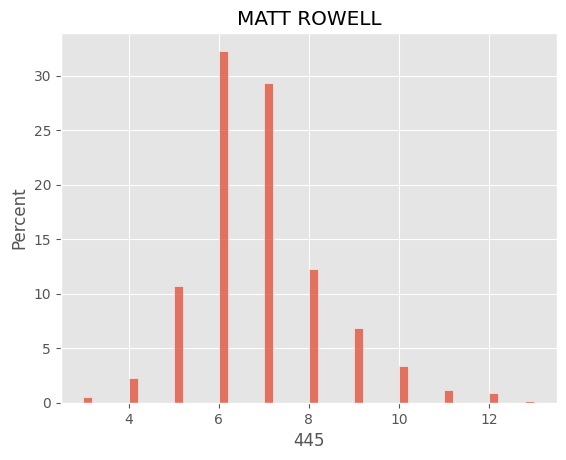

In [25]:
player_lookup = 'MATT ROWELL'
player_idx = points_totals_by_player.query(f"FULL_NAME == '{player_lookup}'").index[0]
sns.histplot(sim_ranks.loc[player_idx], stat='percent')
plt.title(player_lookup);

In [78]:
sim_ranks

,simulation_1_pts,simulation_2_pts,simulation_3_pts,simulation_4_pts,simulation_5_pts,simulation_6_pts,simulation_7_pts,simulation_8_pts,simulation_9_pts,simulation_10_pts,...,simulation_991_pts,simulation_992_pts,simulation_993_pts,simulation_994_pts,simulation_995_pts,simulation_996_pts,simulation_997_pts,simulation_998_pts,simulation_999_pts,simulation_1000_pts
0,70.0,70.0,76.0,75.0,74.0,78.0,72.0,75.0,72.0,76.0,...,77.0,77.0,71.0,71.0,76.0,73.0,74.0,72.0,68.0,76.0
1,191.0,192.0,191.0,189.0,199.0,198.0,197.0,192.0,194.0,187.0,...,192.0,186.0,188.0,185.0,188.0,192.0,201.0,189.0,195.0,184.0
2,52.0,50.0,48.0,52.0,43.0,56.0,47.0,62.0,44.0,50.0,...,48.0,48.0,46.0,44.0,49.0,42.0,61.0,51.0,43.0,52.0
3,71.0,71.0,88.0,88.0,79.0,79.0,86.0,83.0,73.0,77.0,...,80.0,78.0,72.0,72.0,77.0,74.0,82.0,73.0,77.0,85.0
4,192.0,193.0,192.0,190.0,200.0,199.0,198.0,193.0,195.0,188.0,...,193.0,187.0,189.0,186.0,189.0,193.0,202.0,190.0,196.0,185.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
664,666.0,666.0,666.0,666.0,666.0,666.0,666.0,666.0,666.0,666.0,...,666.0,666.0,666.0,666.0,666.0,666.0,666.0,666.0,666.0,666.0
665,7.0,11.0,12.0,10.0,11.0,12.0,9.0,8.0,8.0,7.0,...,12.0,12.0,11.0,10.0,9.0,10.0,13.0,9.0,13.0,10.0
666,667.0,667.0,667.0,667.0,667.0,667.0,667.0,667.0,667.0,667.0,...,667.0,667.0,667.0,667.0,667.0,667.0,667.0,667.0,667.0,667.0
667,668.0,668.0,668.0,668.0,668.0,668.0,668.0,668.0,668.0,668.0,...,668.0,668.0,668.0,668.0,668.0,668.0,668.0,668.0,668.0,668.0


# Nice stripplot

In [69]:
points_totals_by_player.groupby(['TEAM_NAME'])['simulation_mean'].sum().sort_values(ascending=False)

TEAM_NAME
Geelong Cats         100.492
Brisbane Lions        98.674
Western Bulldogs      94.980
Collingwood           91.367
GWS GIANTS            90.427
Adelaide Crows        87.768
Gold Coast SUNS       84.618
Fremantle             83.708
Hawthorn              78.167
Sydney Swans          67.101
Port Adelaide         63.055
St Kilda              63.040
Carlton               60.497
Melbourne             55.866
Essendon              45.169
North Melbourne       37.761
Richmond              32.134
West Coast Eagles      7.176
Name: simulation_mean, dtype: float64

In [ ]:
top_5_players = points_totals_by_player.sort_values(by='simulation_mean', ascending=False).head(5).loc[:,'FULL_NAME'].tolist()

In [ ]:
points_top_5_players_long = (points_totals_by_player
 .loc[points_totals_by_player['FULL_NAME'].isin(top_5_players), ['FULL_NAME'] + points_cols]
 .melt(id_vars='FULL_NAME', value_name='BROWNLOW_VOTES')
)

In [ ]:
import matplotlib.patches as patches
# Colors you provided (one per player, in the same order as top_5_players)
fill_colors_hex = ["#2EC0F9", "#67AAF9", "#9BBDF9", "#C4E0F9", "#77966D"]

def darken_hex(hex_color, factor=0.7):
    """Return a darker shade of the given hex color.
       factor < 1.0 makes it darker (0 = black)."""
    hex_color = hex_color.lstrip('#')
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    r = max(0, min(255, int(r * factor)))
    g = max(0, min(255, int(g * factor)))
    b = max(0, min(255, int(b * factor)))
    return f"#{r:02x}{g:02x}{b:02x}"

edge_colors_hex = [darken_hex(c, factor=0.55) for c in fill_colors_hex]

# Build palette mapping FULL_NAME -> fill color (ensure ordering)
palette = {name: color for name, color in zip(top_5_players, fill_colors_hex)}
edge_palette = {name: edge for name, edge in zip(top_5_players, edge_colors_hex)}

# ----- Plotting -----
#plt.figure(figsize=(14, 8))
fig, ax = plt.subplots(figsize=(14,8))
sns.set_style("whitegrid")

ax = sns.stripplot(
    data=points_top_5_players_long,
    x='FULL_NAME',
    y='BROWNLOW_VOTES',
    hue='FULL_NAME',
    order=top_5_players,       # enforces x-axis order
    palette=palette,           # fill colors per player
    jitter=True,
    size=6,                    # marker size
    marker='o',                # round markers
    edgecolor='none',          # we'll set edges below per collection
    linewidth=0.6,
    alpha=0.95,
    dodge=False,
    legend=False,
    ax=plt.gca()
)

# Force face/edge colors per player collection (Seaborn groups points into PathCollections)
# Collections appear in the same order as the hue levels (top_5_players)
for coll, name in zip(ax.collections, top_5_players):
    face = palette[name]
    edge = edge_palette[name]
    coll.set_facecolor(face)
    coll.set_edgecolor(edge)
    coll.set_linewidth(0.8)
    # ensure markers are filled
    coll.set_alpha(0.95)

# ----- Annotations: player name + range, bold and large -----
grp = points_top_5_players_long.groupby('FULL_NAME')['BROWNLOW_VOTES']
stats = grp.agg(['min','max']).reindex(top_5_players)
stats['range'] = stats['max'] - stats['min']

# Map category name -> x position (0..n-1)
x_positions = {name: i for i, name in enumerate(top_5_players)}

# Place text slightly above the player's max
ymin, ymax = 0, 45             # per your request set chart y-axis 0..45 (use same for offset calc)
y_offset = (ymax - ymin) * 0.03   # small vertical offset

for name, row in stats.iterrows():
    x = x_positions[name]
    y_text = row['max'] + y_offset
    label = f"{name}\n[{int(row['min'])}–{int(row['max'])}]"
    ax.text(
        x, y_text, label,
        ha='center', va='bottom',
        fontsize=16, fontweight='bold', color='#222222'
    )

# ----- Final cosmetic tweaks -----
ax.set_ylim(0, 45)            # set y axis between 0 and 45
ax.set_xlabel("")             # remove x label if desired
ax.set_ylabel("Brownlow votes", fontsize=14)

# remove x-ticks and tick labels
ax.set_xticks([])
ax.set_xticklabels([])

sns.despine(trim=True)
plt.tight_layout()
plt.title("2025 Brownlow XGBoost Prediction\n1,000 simulations", fontsize=22, fontweight='bold', loc='center')
plt.show()

In [ ]:
points_totals_by_player_subset = points_totals_by_player.loc[:,['FULL_NAME', 'TEAM_NAME','simulation_min', 'simulation_max', 'simulation_mean','simulation_std']]

In [ ]:
points_totals_by_player_subset.sort_values(by='simulation_std', ascending=False)

In [ ]:
best_by_team_idx = points_totals_by_player_subset.groupby('TEAM_NAME')['simulation_mean'].idxmax()

In [ ]:
best_by_team = points_totals_by_player_subset.loc[best_by_team_idx]
display(best_by_team)

In [ ]:
points_totals_by_player_subset.query("TEAM_NAME == 'West Coast Eagles'").sort_values(by='simulation_mean', ascending=False)

In [ ]:
df_long =(
df_with_points
 .query("FULL_NAME == 'NICK DAICOS'")
 .loc[:,points_cols]
 .cumsum()
 .reset_index(drop=True)
 .reset_index(names='ROUND')
 #.loc[:,['ROUND_ROUNDNUMBER'] + points_cols]
 .melt(id_vars='ROUND')
)

In [ ]:
plt.figure(figsize=(12,9))
n_levels = df_long['variable'].nunique()
sns.lineplot(
    data=df_long, x='ROUND', y='value', hue='variable',
    palette=['grey'] * n_levels,    # force every hue to be grey
    linewidth=0.6, alpha=0.8, legend=False
)
sns.despine(trim=True)
plt.tight_layout()
plt.show()